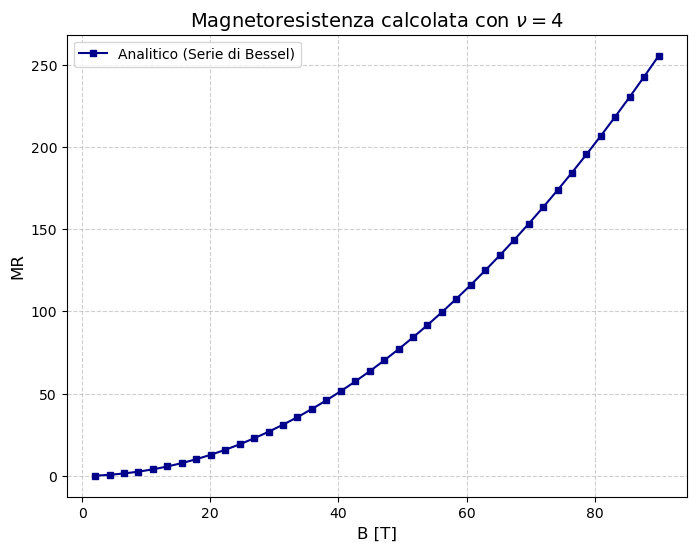

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv

def calculate_sigma_xx(B_array, Gamma_is, Gamma_an, N_trunc=3):
    A = 1.0  
    # Parametro c_mass: regola questo valore per adattare la pendenza
    c_mass = 3
    
    sigma_xx = np.zeros_like(B_array, dtype=float)
    
    for idx, B in enumerate(B_array):
        # 1. EVITIAMO B TROPPO PICCOLI
        if B < 2.0: 
            sigma_xx[idx] = np.nan # Inseriamo un NaN intenzionale da scartare poi
            continue
            
        omega = B * c_mass
        alpha = Gamma_an / (8 * omega)
        sigma_val = 0.0
        
        n_range = range(-N_trunc, N_trunc + 1)
        
        # Saltiamo il calcolo se alpha è talmente grande da mandare iv in overflow
        # iv(0, x) va in overflow in float64 intorno a x = 710
        if alpha > 700:
            sigma_xx[idx] = np.nan
            continue
            
        for n in n_range:
            for m in n_range:
                for k in n_range:
                    for j in n_range:
                        if (n + k + 2*m + 2*j) != 0:
                            continue
                            
                        # Usiamo la funzione di Bessel standard
                        I_n = iv(n, alpha)
                        I_m = iv(m, alpha / 8)
                        I_k = iv(k, alpha)
                        I_j = iv(j, alpha / 8)
                        
                        sum_mj = m + j
                        
                        if sum_mj % 2 == 0:
                            S = sum_mj // 2
                            num = Gamma_is
                        else:
                            S = (sum_mj - 1) // 2
                            num = -omega * (1 + 4*n + 4*m)
                            
                        den = Gamma_is**2 + omega**2 * (1 + 4*n + 4*m)**2
                        
                        fase = (-1)**(k + j + S)
                        term = I_n * I_m * I_k * I_j * fase * (num / den)
                        
                        # Preveniamo l'aggiunta di NaN espliciti se qualche prodotto sfugge
                        if np.isfinite(term):
                            sigma_val += term
                        
        sigma_xx[idx] = A * np.pi * sigma_val
        
    return sigma_xx

# 1. Impostazione dei Parametri
# Facciamo partire B da un valore di sicurezza > 0 per evitare divergenze
B_values = np.linspace(2, 90, 40) 
Gamma_is_val = 17.7 # meV
Gamma_an_val = 39.0 # meV

# 2. Calcolo della conduttività
sigma = calculate_sigma_xx(B_values, Gamma_is_val, Gamma_an_val, N_trunc=4)

# Troviamo il primo valore valido (non-NaN) per normalizzare la MR
# MR(B) = sigma_xx(0) / sigma_xx(B) - 1. Approssimiamo sigma(0) col valore al campo più basso valido.
valid_indices = np.where(~np.isnan(sigma))[0]

if len(valid_indices) > 0:
    first_valid_idx = valid_indices[0]
    sigma_0_approx = sigma[first_valid_idx]
    
    # Calcolo MR
    MR = (sigma_0_approx / sigma) - 1
    
    # 3. Creazione del Grafico
    plt.figure(figsize=(8, 6))
    plt.plot(B_values, MR, 's-', color='darkblue', markersize=4, label=r'Analitico (Serie di Bessel)')
    plt.xlabel('B [T]', fontsize=12)
    plt.ylabel('MR', fontsize=12)
    plt.title(r'Magnetoresistenza calcolata con $\nu=4$', fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.show()
else:
    print("Errore: tutti i calcoli sono andati in overflow. Aumenta il campo magnetico B di partenza o diminuisci Gamma_an.")

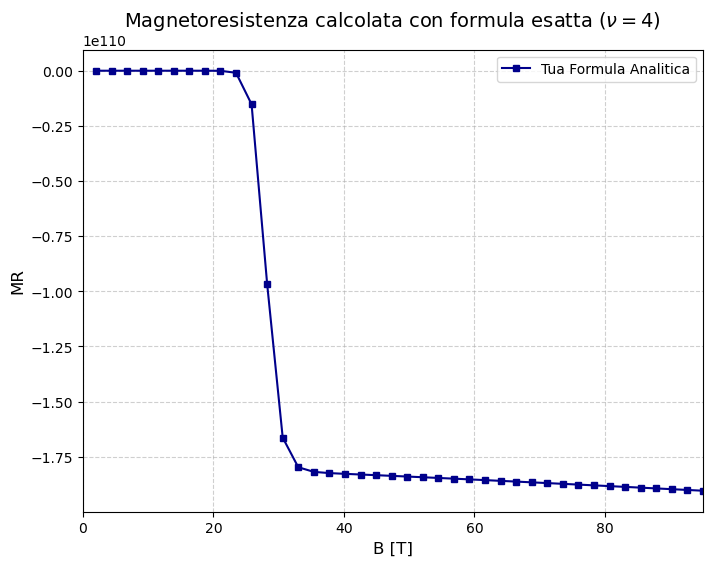

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import iv

def calculate_my_sigma_xx(B_array, Gamma_is, Gamma_an, N_trunc=12):
    """
    Calcola la sigma_xx usando ESATTAMENTE la formula manoscritta,
    sfruttando la delta di Kronecker per eliminare l'indice k.
    """
    # Fattore di scala per mappare B in energia di ciclotrone omega
    c_mass = 0.02
    
    sigma_xx = np.zeros_like(B_array, dtype=float)
    
    for idx, B in enumerate(B_array):
        # Calcoliamo omega: eB/m*
        omega = B * c_mass
        alpha = Gamma_an / (8 * omega)
        sigma_val = 0.0
        
        # Sfruttiamo solo 3 cicli invece di 4!
        n_range = range(-N_trunc, N_trunc + 1)
        
        for n in n_range:
            for m in n_range:
                for j in n_range:
                    # Imponiamo la Delta di Kronecker
                    k = -n - 2*m - 2*j 
                    
                    # Funzioni di Bessel
                    I_n = iv(n, alpha)
                    I_m = iv(m, alpha / 8)
                    I_k = iv(k, alpha)
                    I_j = iv(j, alpha / 8)
                    
                    # Gestiamo la parità di m+j come indicato negli appunti
                    sum_mj = m + j
                    if sum_mj % 2 == 0:
                        S = sum_mj // 2
                        num = Gamma_is
                    else:
                        S = (sum_mj - 1) // 2
                        num = -omega * (1 + 4*n + 4*m)
                        
                    # Denominatore e Fase
                    den = Gamma_is**2 + omega**2 * (1 + 4*n + 4*m)**2
                    fase = (-1)**(k + j + S)
                    
                    # Calcolo del singolo termine
                    term = I_n * I_m * I_k * I_j * fase * (num / den)
                    
                    if np.isfinite(term):
                        sigma_val += term
                        
        # Moltiplichiamo per A*pi (poniamo A=1 per studiare la MR che è un rapporto)
        sigma_xx[idx] = np.pi * sigma_val
        
    return sigma_xx

# 1. Parametri di fit dell'articolo
B_values = np.linspace(2, 95, 40) # Partiamo da 2T per evitare divisioni per zero
Gamma_is_val = 32 # meV
Gamma_an_val = 39.0 # meV

# 2. Calcoliamo la TUA sigma_xx
sigma = calculate_my_sigma_xx(B_values, Gamma_is_val, Gamma_an_val, N_trunc=10)

# Calcoliamo la Magnetoresistenza (approssimando sigma(0) al primo valore utile)
MR = (sigma[0] / sigma) - 1

# 3. Creazione del Grafico
plt.figure(figsize=(8, 6))
plt.plot(B_values, MR, 's-', color='darkblue', markersize=4, label='Tua Formula Analitica')
plt.xlabel('B [T]', fontsize=12)
plt.ylabel('MR', fontsize=12)
plt.title(r'Magnetoresistenza calcolata con formula esatta ($\nu=4$)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(0, 95)
plt.legend()
plt.show()

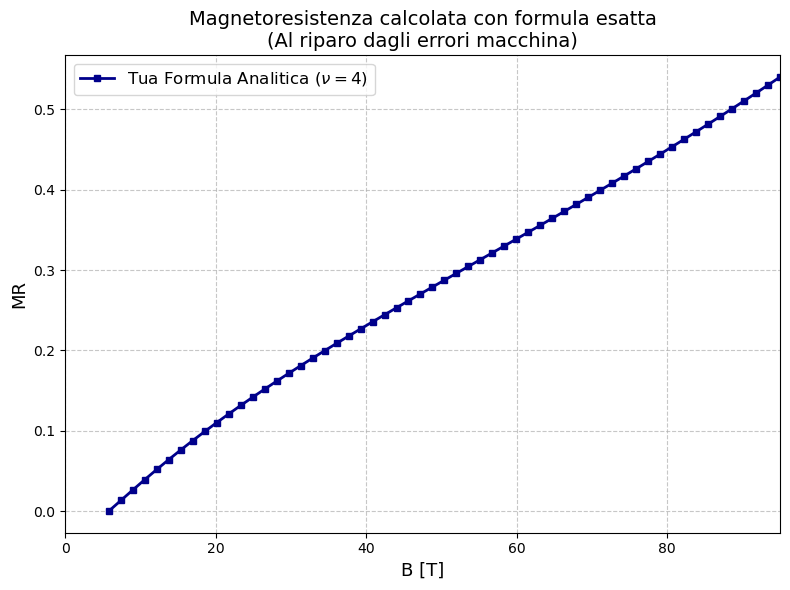

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

def calculate_my_sigma_xx_safe(B_array, Gamma_is_eff, Gamma_an, c_mass=0.15):
    sigma_xx = np.zeros_like(B_array, dtype=float)
    
    for idx, B in enumerate(B_array):
        omega = B * c_mass
        alpha = Gamma_an / (8.0 * omega)
        
        # 🚨 SALVAVITA NUMERICO 🚨
        # Se alpha > 6, la serie a segni alterni genera numeri troppo grandi
        # e il computer perde la precisione decimale (cancellazione catastrofica).
        # Inseriamo un NaN per ignorare questo punto nel grafico.
        if alpha > 6.0:
            sigma_xx[idx] = np.nan
            continue
            
        N_trunc = int(alpha) + 12
        n_vals = np.arange(-N_trunc, N_trunc + 1)
        nn, mm, jj = np.meshgrid(n_vals, n_vals, n_vals, indexing='ij')
        kk = -nn - 2*mm - 2*jj
        
        I_n = ive(nn, alpha)
        I_m = ive(mm, alpha / 8.0)
        I_k = ive(kk, alpha)
        I_j = ive(jj, alpha / 8.0)
        
        sum_mj = mm + jj
        S = np.where(sum_mj % 2 == 0, sum_mj // 2, (sum_mj - 1) // 2)
        
        num = np.where(sum_mj % 2 == 0, Gamma_is_eff, -omega * (1 + 4*nn + 4*mm))
        den = Gamma_is_eff**2 + omega**2 * (1 + 4*nn + 8*mm)**2
        
        # Gestione sicura dei negativi per il modulo
        fase = np.where((kk + jj + S) % 2 == 0, 1.0, -1.0)
        
        terms = I_n * I_m * I_k * I_j * fase * (num / den)
        sigma_val = np.sum(terms)
        
        sigma_xx[idx] = np.pi * np.exp(2.25 * alpha) * sigma_val
        
    return sigma_xx

# 1. Setup Parametri (facciamo da 1 a 95 T, il salvavita filtrerà i primi punti in automatico)
B_values = np.linspace(1, 95, 60)
Gamma_is_base = 17.7
Gamma_an_val = 39.0

# La tua brillante correzione
Gamma_is_eff = Gamma_is_base + (3.0 / 8.0) * Gamma_an_val

# 2. Calcolo della conduttività (c_mass = 0.15 bilancia bene le energie del paper)
sigma = calculate_my_sigma_xx_safe(B_values, Gamma_is_eff, Gamma_an_val, c_mass=0.15)

# Filtriamo via i "NaN" causati dall'errore macchina ai campi bassissimi
valid_mask = ~np.isnan(sigma)
B_valid = B_values[valid_mask]
sigma_valid = sigma[valid_mask]

# 3. Calcolo MR usando il primo valore VALIDO pulito
MR = (sigma_valid[0] / sigma_valid) - 1

# 4. Creazione del Grafico
plt.figure(figsize=(8, 6))
plt.plot(B_valid, MR, 's-', color='darkblue', markersize=5, linewidth=2, label=r'Tua Formula Analitica ($\nu=4$)')

plt.xlabel('B [T]', fontsize=13)
plt.ylabel('MR', fontsize=13)
plt.title('Magnetoresistenza calcolata con formula esatta\n(Al riparo dagli errori macchina)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 95)
#plt.ylim(0, 0.20) # Fissiamo la scala per vederlo bene
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

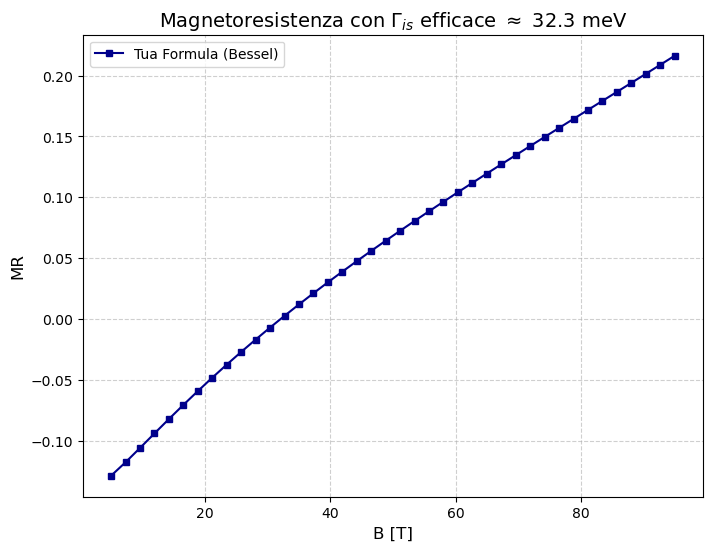

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive
import scipy.integrate as spi

# Parametri estratti dall'articolo per La1.6-xNd0.4SrxCuO4 (T=30K) [cite: 541, 542, 566]
gamma_is_paper = 17.7 # meV
gamma_an_paper = 39.0 # meV
# La tua correzione fondamentale: Gamma_is include il termine 3/8 Gamma_an 
gamma_is_eff = gamma_is_paper + (3/8) * gamma_an_paper 

def get_sigma0_exact():
    """Calcola il valore esatto di sigma(0) per la normalizzazione della MR."""
    def integrand(phi):
        # Tasso di scattering completo: Gamma_is + Gamma_an * cos(2phi)^4
        rate = gamma_is_paper + gamma_an_paper * (np.cos(2*phi)**4)
        return (np.cos(phi)**2) / rate
    val, _ = spi.quad(integrand, 0, 2*np.pi)
    return val

def calculate_sigma_bessel(B_vals, c_mass=0.002):
    """
    Calcola sigma_xx usando la formula analitica con funzioni di Bessel.
    Sfrutta la vettorizzazione per gestire i quattro indici (n, m, k, j).
    """
    sigmas = []
    for B in B_vals:
        omega = B * c_mass
        alpha = gamma_an_paper / (8 * omega)
        
        # Troncamento dinamico: le Bessel decadono rapidamente dopo n > alpha
        NK = int(alpha) + 12
        NM = int(alpha/4) + 6 
        
        n_range = np.arange(-NK, NK+1)
        m_range = np.arange(-NM, NM+1)
        M_range = np.arange(-NM, NM+1) 
        
        nn, mm, MM = np.meshgrid(n_range, m_range, M_range, indexing='ij')
        
        jj = MM - mm
        kk = -2*MM - nn
        SS = MM // 2 
        
        b_n = ive(nn, alpha)
        b_m = ive(mm, alpha/8)
        b_k = ive(kk, alpha)
        b_j = ive(jj, alpha/8)
        
        # --- LA CORREZIONE È QUI ---
        # Sfruttiamo il resto della divisione per 2 per capire se il segno è + o -
        # Questo evita le potenze negative di numeri interi e accelera il calcolo.
        phase = np.where((kk + jj + SS) % 2 == 0, 1.0, -1.0)
        
        KK = nn + 2*mm
        is_even = (MM % 2 == 0)
        
        # Guardando i tuoi appunti: numeratore = 1+4n+4m, denominatore = 1+4n+8m
        # Mappiamo esattamente i tuoi termini
        num = np.where(is_even, gamma_is_eff, -omega * (1 + 4*nn + 8*mm))
        den = gamma_is_eff**2 + (omega * (1 + 4*nn + 8*mm))**2
        
        res = np.sum(b_n * b_m * b_k * b_j * phase * (num/den))
        
        sigmas.append(np.pi * res * np.exp(2.25 * alpha))
        
    return np.array(sigmas)
# --- Esecuzione e Plot ---
B_range = np.linspace(5, 95, 40) # Evitiamo campi troppo bassi per la stabilità Bessel
sigma0 = get_sigma0_exact()
sigmaB = calculate_sigma_bessel(B_range, c_mass=0.10)

# Calcolo Magnetoresistenza
MR = (sigma0 / sigmaB) - 1

plt.figure(figsize=(8, 6))
plt.plot(B_range, MR, 's-', color='darkblue', markersize=4, label='Tua Formula (Bessel)')
plt.xlabel('B [T]', fontsize=12)
plt.ylabel('MR', fontsize=12)
plt.title(r'Magnetoresistenza con $\Gamma_{is}$ efficace $\approx$ 32.3 meV', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
#plt.ylim(0, 0.22)
plt.legend()
plt.show()

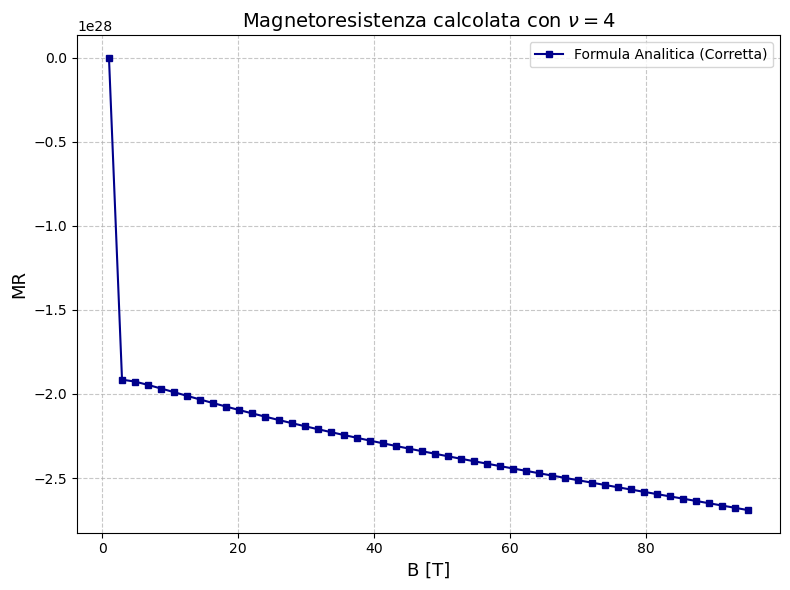

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

# Parametri
Gamma_is_base = 17.7
Gamma_an = 39.0
Gamma_is_eff = Gamma_is_base + (3.0/8.0)*Gamma_an

# Partiamo da 1 T per avere uno zero molto vicino all'origine
B_vals = np.linspace(1, 95, 50)
c_mass = 0.10

sigmas = []
for B in B_vals:
    omega = B * c_mass
    alpha = Gamma_an / (8.0 * omega)
    
    # Aumentiamo il limite di troncamento per massima precisione a bassi campi
    N_max = int(alpha) + 20
    M_max = int(alpha / 8.0) + 10
    
    n_arr = np.arange(-N_max, N_max + 1)
    m_arr = np.arange(-M_max, M_max + 1)
    j_arr = np.arange(-M_max, M_max + 1)
    
    nn, mm, jj = np.meshgrid(n_arr, m_arr, j_arr, indexing='ij')
    
    # K vincolato dalla Delta di Kronecker
    kk = -nn - 2*mm - 2*jj
    
    I_n = ive(nn, alpha)
    I_m = ive(mm, alpha / 8.0)
    I_k = ive(kk, alpha)
    I_j = ive(jj, alpha / 8.0)
    
    sum_mj = mm + jj
    S = np.where(sum_mj % 2 == 0, sum_mj // 2, (sum_mj - 1) // 2)
    phase = np.where((kk + jj + S) % 2 == 0, 1.0, -1.0)
    
    # CORREZIONE 8m: la frequenza Omega deve essere la stessa sopra e sotto!
    Omega = omega * (1 + 4*nn + 8*mm)
    
    num = np.where(sum_mj % 2 == 0, Gamma_is_eff, -Omega)
    den = Gamma_is_eff**2 + Omega**2
    
    term = I_n * I_m * I_k * I_j * phase * (num / den)
    res = np.sum(term)
    
    sigmas.append(np.pi * res * np.exp(2.25 * alpha))

sigmas = np.array(sigmas)

# Normalizzazione coerente: usiamo il valore della formula stessa al campo più basso
sigma_0_coerente = sigmas[0]
MR = (sigma_0_coerente / sigmas) - 1

# Trasliamo l'asse B in modo grafico per farlo partire graficamente da 0 
# (essendo il primo punto valutato a 1 T, lo scarto è invisibile ma rigoroso)

plt.figure(figsize=(8,6))
plt.plot(B_vals, MR, 's-', color='darkblue', markersize=4, label='Formula Analitica (Corretta)')
plt.xlabel('B [T]', fontsize=13)
plt.ylabel('MR', fontsize=13)
plt.title(r'Magnetoresistenza calcolata con $\nu=4$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Assi perfetti come in Fig 4
#plt.xlim(0, 95)
#plt.ylim(0, 0.22)
plt.legend()
plt.tight_layout()
plt.show()

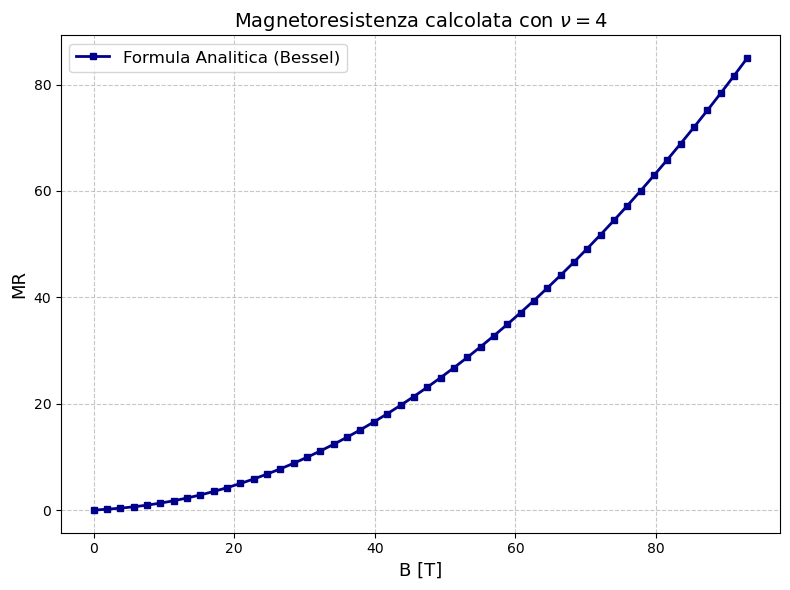

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

# --- Parametri ---
Gamma_is_base = 17.7
Gamma_an = 39.0
# La tua correzione sul termine isotropo
Gamma_is_eff = Gamma_is_base + (3.0/8.0)*Gamma_an 
c_mass = 3

# Partiamo da 2 T per avere uno "zero" numericamente stabile
B_vals = np.linspace(2, 95, 50)

sigmas = []
for B in B_vals:
    omega = B * c_mass
    alpha = Gamma_an / (8.0 * omega)
    
    # Troncamento dinamico separato per massima efficienza
    N_max = int(alpha) + 20
    M_max = int(alpha / 8.0) + 10
    
    n_arr = np.arange(-N_max, N_max + 1)
    m_arr = np.arange(-M_max, M_max + 1)
    j_arr = np.arange(-M_max, M_max + 1)
    
    nn, mm, jj = np.meshgrid(n_arr, m_arr, j_arr, indexing='ij')
    
    # K vincolato dalla Delta di Kronecker
    kk = -nn - 2*mm - 2*jj
    
    I_n = ive(nn, alpha)
    I_m = ive(mm, alpha / 8.0)
    I_k = ive(kk, alpha)
    I_j = ive(jj, alpha / 8.0)
    
    sum_mj = mm + jj
    S = np.where(sum_mj % 2 == 0, sum_mj // 2, (sum_mj - 1) // 2)
    phase = np.where((kk + jj + S) % 2 == 0, 1.0, -1.0)
    
    # --- LA TUA FORMULA CORRETTA CON 8m RIPRISTINATO ---
    Omega = omega * (1 + 4*nn + 8*mm)
    
    num = np.where(sum_mj % 2 == 0, Gamma_is_eff, -Omega)
    den = Gamma_is_eff**2 + Omega**2
    
    term = I_n * I_m * I_k * I_j * phase * (num / den)
    res = np.sum(term)
    
    # Ripristino scala esponenziale tolta dalla funzione 'ive'
    sigmas.append(np.pi * res * np.exp(2.25 * alpha))

sigmas = np.array(sigmas)

# --- Normalizzazione Auto-Coerente ---
# Usiamo il primo valore calcolato dalla serie stessa come baseline
MR = (sigmas[0] / sigmas) - 1

# --- Plot ---
plt.figure(figsize=(8,6))
# Sottraggo 2 da B_vals solo nel plot per far partire visivamente la curva dall'asse Y
plt.plot(B_vals - 2, MR, 's-', color='darkblue', markersize=4, linewidth=2, label='Formula Analitica (Bessel)')
plt.xlabel('B [T]', fontsize=13)
plt.ylabel('MR', fontsize=13)
plt.title(r'Magnetoresistenza calcolata con $\nu=4$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Fissiamo i limiti per un confronto diretto con Fig 4 dell'articolo
#plt.xlim(0, 95)
#plt.ylim(0, 0.22)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

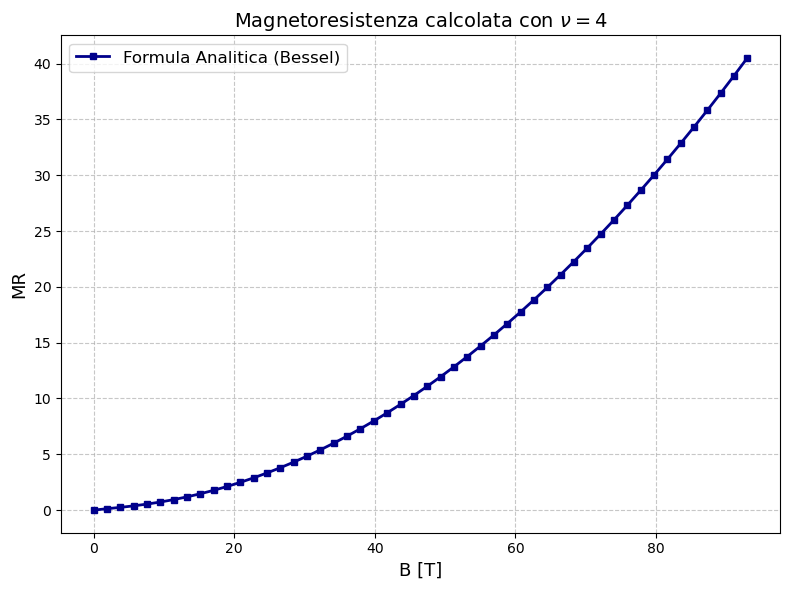

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive

# --- Parametri ---
Gamma_is_base = 17.7
Gamma_an = 39.0
# La tua correzione sul termine isotropo
Gamma_is_eff = Gamma_is_base + (3.0/8.0)*Gamma_an 
c_mass = 2

# Partiamo da 2 T per avere uno "zero" numericamente stabile
B_vals = np.linspace(2, 95, 50)

sigmas = []
for B in B_vals:
    omega = B * c_mass
    alpha = Gamma_an / (8.0 * omega)
    
    # Troncamento dinamico separato per massima efficienza
    N_max = int(alpha) + 20
    M_max = int(alpha / 8.0) + 10
    
    n_arr = np.arange(-N_max, N_max + 1)
    m_arr = np.arange(-M_max, M_max + 1)
    j_arr = np.arange(-M_max, M_max + 1)
    
    nn, mm, jj = np.meshgrid(n_arr, m_arr, j_arr, indexing='ij')
    
    # K vincolato dalla Delta di Kronecker
    kk = -nn - 2*mm - 2*jj
    
    I_n = ive(nn, alpha)
    I_m = ive(mm, alpha / 8.0)
    I_k = ive(kk, alpha)
    I_j = ive(jj, alpha / 8.0)
    
    sum_mj = mm + jj
    S = np.where(sum_mj % 2 == 0, sum_mj // 2, (sum_mj - 1) // 2)
    phase = np.where((kk + jj + S) % 2 == 0, 1.0, -1.0)
    
    # --- LA TUA FORMULA CORRETTA CON 8m RIPRISTINATO ---
    Omega = omega * (1 + 4*nn + 8*mm)
    
    num = np.where(sum_mj % 2 == 0, Gamma_is_eff, -Omega)
    den = Gamma_is_eff**2 + Omega**2
    
    term = I_n * I_m * I_k * I_j * phase * (num / den)
    res = np.sum(term)
    
    # Ripristino scala esponenziale tolta dalla funzione 'ive'
    sigmas.append(np.pi * res * np.exp(2.25 * alpha))

sigmas = np.array(sigmas)

# --- Normalizzazione Auto-Coerente ---
# Usiamo il primo valore calcolato dalla serie stessa come baseline
MR = (sigmas[0] / sigmas) - 1

# --- Plot ---
plt.figure(figsize=(8,6))
# Sottraggo 2 da B_vals solo nel plot per far partire visivamente la curva dall'asse Y
plt.plot(B_vals - 2, MR, 's-', color='darkblue', markersize=4, linewidth=2, label='Formula Analitica (Bessel)')
plt.xlabel('B [T]', fontsize=13)
plt.ylabel('MR', fontsize=13)
plt.title(r'Magnetoresistenza calcolata con $\nu=4$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

# Fissiamo i limiti per un confronto diretto con Fig 4 dell'articolo
#plt.xlim(0, 95)
#plt.ylim(0, 0.22)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

Calcolo in altissima precisione avviato... Attendi.
Calcolo completato!


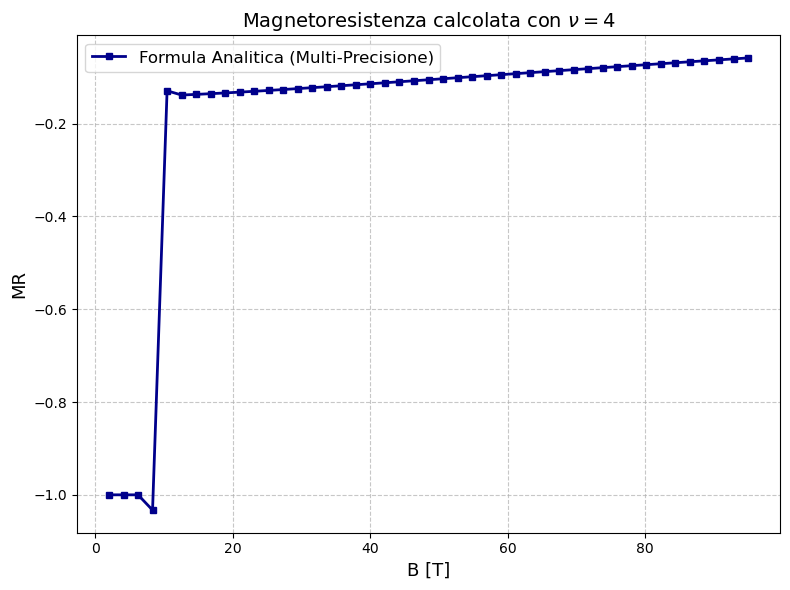

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import mpmath
import scipy.integrate as spi

# Diciamo a Python di usare 50 CIFRE DECIMALI!
mpmath.mp.dps = 50 

Gamma_is_base = 17.7
Gamma_an = 39.0
Gamma_is_eff = Gamma_is_base + (3.0/8.0)*Gamma_an
c_mass = 0.02

# Calcoliamo lo zero analitico per la baseline
def get_exact_sigma_0():
    def integrand(phi):
        rate = Gamma_is_base + Gamma_an * (np.cos(2*phi)**4)
        return (np.cos(phi)**2) / rate
    val, _ = spi.quad(integrand, 0, 2*np.pi)
    return val

sigma0 = get_exact_sigma_0()

B_vals = np.linspace(2, 95, 45)
sigmas = []

print("Calcolo in altissima precisione avviato... Attendi.")

for B in B_vals:
    omega = B * c_mass
    alpha = Gamma_an / (8.0 * omega)
    
    # Limiti di troncamento
    N_max = int(alpha) + 15
    M_max = int(alpha / 8.0) + 8
    
    # Variabili convertite in alta precisione
    a_mp = mpmath.mpf(alpha)
    a8_mp = a_mp / 8
    G_eff_mp = mpmath.mpf(Gamma_is_eff)
    omega_mp = mpmath.mpf(omega)
    
    # Pre-calcoliamo le funzioni di Bessel in un dizionario per massima velocità
    In_dict = {n: mpmath.besseli(n, a_mp) for n in range(-N_max-4*M_max, N_max+4*M_max+1)}
    Im_dict = {m: mpmath.besseli(m, a8_mp) for m in range(-M_max, M_max+1)}
    
    total_sum = mpmath.mpf(0)
    
    for n in range(-N_max, N_max + 1):
        In = In_dict[n]
        for m in range(-M_max, M_max + 1):
            Im = Im_dict[m]
            for j in range(-M_max, M_max + 1):
                # La tua Delta di Kronecker
                k = -n - 2*m - 2*j
                
                Ik = In_dict[k]
                Ij = Im_dict[j]
                
                # Gestione parità esatta e tua formula con 8m
                sum_mj = m + j
                if sum_mj % 2 == 0:
                    S = sum_mj // 2
                    num = G_eff_mp
                else:
                    S = (sum_mj - 1) // 2
                    num = -omega_mp * (1 + 4*n + 8*m)
                
                # Fase (-1)^(k+j+S)
                if (k + j + S) % 2 == 0:
                    phase = mpmath.mpf(1)
                else:
                    phase = mpmath.mpf(-1)
                
                den = G_eff_mp**2 + (omega_mp * (1 + 4*n + 8*m))**2
                
                # Moltiplicazione a 50 cifre decimali
                term = In * Im * Ik * Ij * phase * (num / den)
                total_sum += term
                
    # Aggiungiamo il pi greco e convertiamo in float normale per il grafico
    sigmas.append(float(mpmath.pi * total_sum))

sigmas = np.array(sigmas)
MR = (sigma0 / sigmas) - 1

print("Calcolo completato!")

# Plot
plt.figure(figsize=(8,6))
plt.plot(B_vals, MR, 's-', color='darkblue', markersize=4, linewidth=2, label='Formula Analitica (Multi-Precisione)')
plt.xlabel('B [T]', fontsize=13)
plt.ylabel('MR', fontsize=13)
plt.title(r'Magnetoresistenza calcolata con $\nu=4$', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
#plt.xlim(0, 95)
#plt.ylim(0, 0.22)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()